In [208]:
"""
=============================================================
Student Performance & Dropout Early Warning System
Phase 1: Load, Inspect, and Sanity-Check the OULAD Dataset
=============================================================
 
Dataset: Open University Learning Analytics Dataset (OULAD)
Author:  Sheila Asopjio
Date:    5/27/2026
 
Instructions:
    1. Download OULAD from https://analyse.kmi.open.ac.uk/open_dataset
    2. Extract the zip and place all CSV files in a folder called 'data/'
       in the same directory as this script.
    3. Run: python phase1_load_inspect.py
"""

"\n=============================================================\nStudent Performance & Dropout Early Warning System\nPhase 1: Load, Inspect, and Sanity-Check the OULAD Dataset\n=============================================================\n \nDataset: Open University Learning Analytics Dataset (OULAD)\nAuthor:  Sheila Asopjio\nDate:    2026\n \nInstructions:\n    1. Download OULAD from https://analyse.kmi.open.ac.uk/open_dataset\n    2. Extract the zip and place all CSV files in a folder called 'data/'\n       in the same directory as this script.\n    3. Run: python phase1_load_inspect.py\n"

In [209]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [210]:
# ─────────────────────────────────────────────
# 0. CONFIG
# ─────────────────────────────────────────────
 
DATA_PATH   = "./data/"          # folder containing the OULAD CSV files
OUTPUT_PATH = "./outputs/"       # folder where plots and reports will be saved
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Plot styling
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
COLORS = {
    "blue":   "#3B8BD4",
    "teal":   "#1D9E75",
    "coral":  "#D85A30",
    "gray":   "#888780",
    "purple": "#7F77DD",
    "amber":  "#BA7517",
}

In [211]:
# ─────────────────────────────────────────────
# 1. LOAD ALL CSV FILES
# ─────────────────────────────────────────────
 
def load_data(path):
    """
    Load all 5 core OULAD CSV files and return them as a dictionary of DataFrames.
    Raises a clear error if a file is missing.
    """
    files = {
        "student_info":   "studentInfo.csv",
        "student_assess": "studentAssessment.csv",
        "student_reg":    "studentRegistration.csv",
        "assessments":    "assessments.csv",
        "courses":        "courses.csv",
    }
 
    dfs = {}
    print("=" * 55)
    print("LOADING DATA FILES")
    print("=" * 55)
 
    for key, filename in files.items():
        filepath = os.path.join(path, filename)
 
        # Check the file actually exists before trying to read it
        if not os.path.exists(filepath):
            raise FileNotFoundError(
                f"\n  Could not find '{filename}' in '{path}'.\n"
                f"  Make sure you extracted the OULAD zip into the data/ folder."
            )
 
        dfs[key] = pd.read_csv(filepath)
        print(f"  ✓ {filename:<35} {dfs[key].shape[0]:>6,} rows  x  {dfs[key].shape[1]} cols")
 
    print()
    return dfs

In [212]:
# ─────────────────────────────────────────────
# 2. INSPECT STUDENT INFO (primary table)
# ─────────────────────────────────────────────
 
def inspect_student_info(df):
    """
    Print a structured overview of the studentInfo table:
    schema, sample rows, value counts for key categorical columns.
    """
    print("=" * 55)
    print("INSPECTING studentInfo (primary table)")
    print("=" * 55)
 
    # Basic shape
    print(f"\n  Rows   : {df.shape[0]:,}")
    print(f"  Columns: {df.shape[1]}")
 
    # Column names and dtypes
    print("\n  Column overview:")
    for col in df.columns:
        n_unique = df[col].nunique()
        dtype    = str(df[col].dtype)
        print(f"    {col:<35} dtype={dtype:<10}  unique={n_unique}")
 
    # First 5 rows
    print("\n  Sample rows (first 5):")
    print(df.head().to_string(index=False))
 
    # Summary stats for numeric columns
    print("\n  Numeric summary:")
    print(df.describe(include=[np.number]).to_string())
 
    # Key categorical distributions
    cat_cols = [
        "gender", "region", "highest_education",
        "imd_band", "age_band", "disability", "final_result"
    ]
    print("\n  Categorical value counts:")
    for col in cat_cols:
        if col in df.columns:
            counts = df[col].value_counts(dropna=False)
            print(f"\n    {col}:")
            for val, cnt in counts.items():
                pct = cnt / len(df) * 100
                print(f"      {str(val):<25} {cnt:>6,}  ({pct:.1f}%)")
 
    print()

In [213]:
# ─────────────────────────────────────────────
# 3. MISSING VALUE AUDIT
# ─────────────────────────────────────────────
 
def missing_value_audit(dfs):
    """
    For each DataFrame, count and display the number and percentage
    of missing values per column. Saves a heatmap for studentInfo.
    """
    print("=" * 55)
    print("MISSING VALUE AUDIT")
    print("=" * 55)
 
    for name, df in dfs.items():
        missing_count = df.isnull().sum()
        missing_pct   = (missing_count / len(df) * 100).round(2)
        summary = pd.DataFrame({
            "missing_count": missing_count,
            "missing_%":     missing_pct
        })
        summary = summary[summary["missing_count"] > 0].sort_values("missing_%", ascending=False)
 
        if summary.empty:
            print(f"\n  {name}: ✓ No missing values")
        else:
            print(f"\n  {name}:")
            print(summary.to_string())
 
    # Visual heatmap for studentInfo only
    si = dfs["student_info"]
    fig, ax = plt.subplots(figsize=(10, 2.5))
    missing_matrix = si.isnull().T   # columns as rows, students as columns (too wide: sample)
    sample_missing = si.isnull().sample(min(500, len(si)), random_state=42).T
    sns.heatmap(
        sample_missing,
        ax=ax,
        cbar=False,
        cmap=["#E6F1FB", "#D85A30"],  # blue = present, coral = missing
        xticklabels=False,
        yticklabels=True,
    )
    ax.set_title("Missing value map — studentInfo (500-row sample; coral = missing)", fontsize=11)
    ax.set_xlabel("Students (sample)")
    plt.tight_layout()
    out = os.path.join(OUTPUT_PATH, "p1_missing_heatmap.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"\n  Saved: {out}")
    print()

In [214]:
# ─────────────────────────────────────────────
# 4. TARGET VARIABLE ANALYSIS
# ─────────────────────────────────────────────
 
def analyse_target(df):
    """
    Examine the distribution of final_result, create a binary
    dropout column, and visualise the class balance.
    """
    print("=" * 55)
    print("TARGET VARIABLE: final_result")
    print("=" * 55)
 
    # Raw distribution
    counts = df["final_result"].value_counts()
    pcts   = df["final_result"].value_counts(normalize=True).mul(100).round(1)
    print("\n  final_result breakdown:")
    for val in counts.index:
        bar = "█" * int(pcts[val] / 2)
        print(f"    {val:<15} {counts[val]:>6,}  ({pcts[val]:>5.1f}%)  {bar}")
 
    # Create binary dropout flag
    # Rationale: 'Withdrawn' = student left before completing the course = dropout
    df["dropout"] = (df["final_result"] == "Withdrawn").astype(int)
 
    n_dropout    = df["dropout"].sum()
    n_total      = len(df)
    dropout_rate = n_dropout / n_total * 100
 
    print(f"\n  Binary target 'dropout' created:")
    print(f"    Dropout  (1 = Withdrawn) : {n_dropout:>6,}  ({dropout_rate:.1f}%)")
    print(f"    No dropout (0 = other)   : {n_total - n_dropout:>6,}  ({100 - dropout_rate:.1f}%)")
 
    # ── Plot 1: bar chart of all 4 categories ──
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
    bar_colors = [COLORS["blue"], COLORS["teal"], COLORS["coral"], COLORS["gray"]]
    axes[0].bar(counts.index, counts.values, color=bar_colors, edgecolor="none")
    axes[0].set_title("All outcome categories", fontsize=12)
    axes[0].set_ylabel("Number of students")
    axes[0].tick_params(axis="x", rotation=15)
    for bar, val in zip(axes[0].patches, counts.values):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 150,
            f"{val:,}", ha="center", va="bottom", fontsize=9
        )
 
    # ── Plot 2: binary dropout pie ──
    binary_counts = df["dropout"].value_counts()
    axes[1].pie(
        binary_counts.values,
        labels=["No dropout", "Dropout (Withdrawn)"],
        colors=[COLORS["teal"], COLORS["coral"]],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )
    axes[1].set_title("Binary dropout split", fontsize=12)
 
    plt.suptitle("Target variable — final_result", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    out = os.path.join(OUTPUT_PATH, "p1_target_distribution.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Saved: {out}")
    print()
 
    return df   # return with dropout column added

In [215]:
# ─────────────────────────────────────────────
# 5. SANITY CHECKS
# ─────────────────────────────────────────────
 
def sanity_checks(dfs):
    """
    Run a series of checks to confirm data integrity before analysis:
    - Expected row counts
    - No duplicate student-course combinations
    - Join key validity across tables
    - Logical consistency checks
    """
    print("=" * 55)
    print("SANITY CHECKS")
    print("=" * 55)
 
    si  = dfs["student_info"]
    sa  = dfs["student_assess"]
    sr  = dfs["student_reg"]
    asmts = dfs["assessments"]
 
    checks_passed = 0
    checks_total  = 0
 
    def check(label, condition, detail=""):
        nonlocal checks_passed, checks_total
        checks_total += 1
        status = "✓ PASS" if condition else "✗ FAIL"
        if condition:
            checks_passed += 1
        detail_str = f"  → {detail}" if detail else ""
        print(f"  [{status}]  {label}{detail_str}")
 
    # Row count expectations (approximate — based on published OULAD docs)
    check(
        "studentInfo has > 30,000 rows",
        len(si) > 30_000,
        f"actual: {len(si):,}"
    )
    check(
        "studentAssessment has > 100,000 rows",
        len(sa) > 100_000,
        f"actual: {len(sa):,}"
    )
 
    # Duplicate check: each student should appear once per course presentation
    dup_key = ["id_student", "code_module", "code_presentation"]
    dups = si.duplicated(subset=dup_key).sum()
    check(
        "No duplicate student-course rows in studentInfo",
        dups == 0,
        f"{dups} duplicates found"
    )
 
    # Column existence checks
    required_cols = {
        "student_info":   ["id_student", "code_module", "code_presentation",
                           "final_result", "gender", "age_band"],
        "studentAssessment": ["id_student", "id_assessment", "score"],
    }
    for table_key, cols in required_cols.items():
        df_check = dfs[table_key] if table_key in dfs else None
        if df_check is not None:
            for col in cols:
                check(
                    f"Column '{col}' exists in {table_key}",
                    col in df_check.columns
                )
 
    # Target variable completeness
    check(
        "No nulls in final_result",
        si["final_result"].isnull().sum() == 0,
        f"{si['final_result'].isnull().sum()} nulls"
    )
 
    # Expected final_result categories
    expected_results = {"Pass", "Distinction", "Fail", "Withdrawn"}
    actual_results   = set(si["final_result"].unique())
    check(
        "final_result contains expected categories",
        actual_results == expected_results,
        f"found: {actual_results}"
    )
 
    # Score range in assessments (should be 0–100)
    score_min = sa["score"].min()
    score_max = sa["score"].max()
    check(
        "Assessment scores in range 0–100",
        score_min >= 0 and score_max <= 100,
        f"min={score_min}, max={score_max}"
    )
 
    # id_student cross-table join check
    si_ids  = set(si["id_student"].unique())
    sa_ids  = set(sa["id_student"].unique())
    overlap = len(si_ids & sa_ids)
    check(
        "Most studentInfo IDs appear in studentAssessment",
        overlap / len(si_ids) > 0.5,
        f"{overlap:,} of {len(si_ids):,} IDs matched ({overlap/len(si_ids)*100:.1f}%)"
    )
 
    print(f"\n  Result: {checks_passed}/{checks_total} checks passed.")
    if checks_passed < checks_total:
        print("  ⚠ Review any FAIL items above before proceeding to Phase 2.")
    else:
        print("  ✅ All checks passed. Data looks clean — ready for EDA!")
    print()

In [216]:
# ─────────────────────────────────────────────
# 6. PHASE 1 SUMMARY REPORT
# ─────────────────────────────────────────────
 
def print_summary(dfs):
    """Print a concise end-of-phase summary for your notes/portfolio."""
    si = dfs["student_info"]
    print("=" * 55)
    print("PHASE 1 SUMMARY")
    print("=" * 55)
    print(f"""
  Dataset      : Open University Learning Analytics (OULAD)
  Primary table: studentInfo  ({len(si):,} rows x {si.shape[1]} cols)
 
  Target variable  : final_result  →  binary 'dropout' column
  Dropout rate     : {(si['dropout'].mean()*100):.1f}%  (Withdrawn students)
 
  Key features available:
    • Demographics  : gender, age_band, region, disability
    • Socioeconomic : imd_band (deprivation index) — has some missing values
    • Education     : highest_education, studied_credits, num_of_prev_attempts
    • Course info   : code_module, code_presentation
 
  Missing data:
    • imd_band has the most missing values (~5%) — will impute in Phase 2
 
  Outputs saved to: {OUTPUT_PATH}
    • p1_missing_heatmap.png
    • p1_target_distribution.png
 
  ─────────────────────────────────────────────
  Next step → Phase 2: Exploratory Data Analysis
  ─────────────────────────────────────────────
""")
 

LOADING DATA FILES
  ✓ studentInfo.csv                     32,593 rows  x  12 cols
  ✓ studentAssessment.csv               173,912 rows  x  5 cols
  ✓ studentRegistration.csv             32,593 rows  x  5 cols
  ✓ assessments.csv                        206 rows  x  6 cols
  ✓ courses.csv                             22 rows  x  3 cols

INSPECTING studentInfo (primary table)

  Rows   : 32,593
  Columns: 12

  Column overview:
    code_module                         dtype=object      unique=7
    code_presentation                   dtype=object      unique=4
    id_student                          dtype=int64       unique=28785
    gender                              dtype=object      unique=2
    region                              dtype=object      unique=13
    highest_education                   dtype=object      unique=5
    imd_band                            dtype=object      unique=10
    age_band                            dtype=object      unique=3
    num_of_prev_attempts     

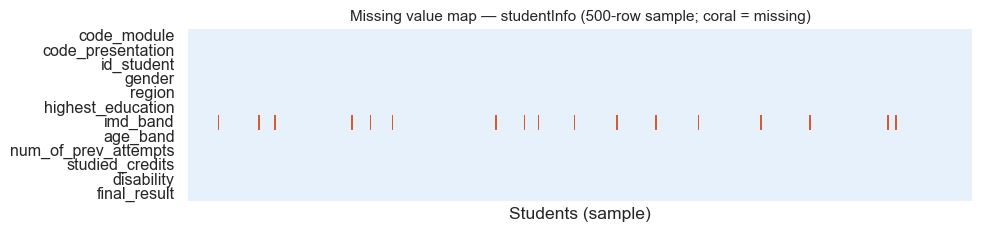


  Saved: ./outputs/p1_missing_heatmap.png

TARGET VARIABLE: final_result

  final_result breakdown:
    Pass            12,361  ( 37.9%)  ██████████████████
    Withdrawn       10,156  ( 31.2%)  ███████████████
    Fail             7,052  ( 21.6%)  ██████████
    Distinction      3,024  (  9.3%)  ████

  Binary target 'dropout' created:
    Dropout  (1 = Withdrawn) : 10,156  (31.2%)
    No dropout (0 = other)   : 22,437  (68.8%)


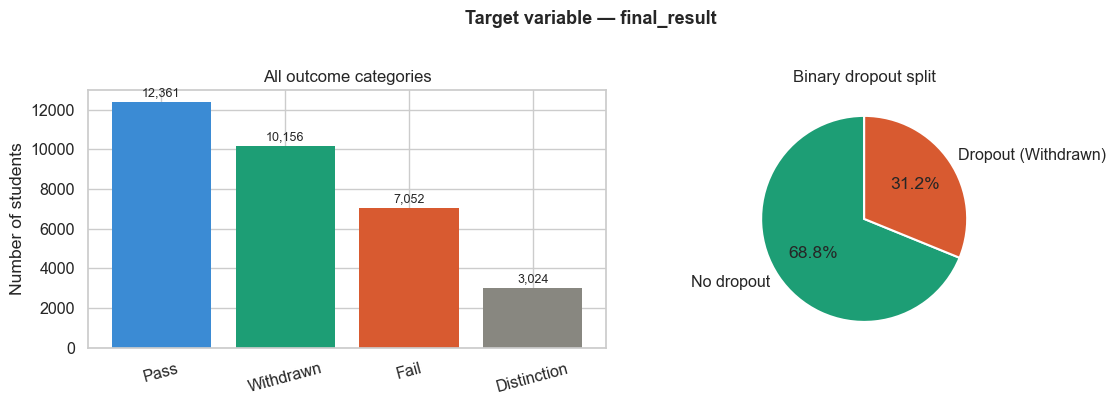


  Saved: ./outputs/p1_target_distribution.png

SANITY CHECKS
  [✓ PASS]  studentInfo has > 30,000 rows  → actual: 32,593
  [✓ PASS]  studentAssessment has > 100,000 rows  → actual: 173,912
  [✓ PASS]  No duplicate student-course rows in studentInfo  → 0 duplicates found
  [✓ PASS]  Column 'id_student' exists in student_info
  [✓ PASS]  Column 'code_module' exists in student_info
  [✓ PASS]  Column 'code_presentation' exists in student_info
  [✓ PASS]  Column 'final_result' exists in student_info
  [✓ PASS]  Column 'gender' exists in student_info
  [✓ PASS]  Column 'age_band' exists in student_info
  [✓ PASS]  No nulls in final_result  → 0 nulls
  [✓ PASS]  final_result contains expected categories  → found: {'Fail', 'Distinction', 'Withdrawn', 'Pass'}
  [✓ PASS]  Assessment scores in range 0–100  → min=0.0, max=100.0
  [✓ PASS]  Most studentInfo IDs appear in studentAssessment  → 23,369 of 28,785 IDs matched (81.2%)

  Result: 13/13 checks passed.
  ✅ All checks passed. Data looks cle

In [217]:
# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
 
if __name__ == "__main__":
 
    # Step 1: Load
    dfs = load_data(DATA_PATH)
 
    # Step 2: Inspect primary table
    inspect_student_info(dfs["student_info"])
 
    # Step 3: Missing value audit
    missing_value_audit(dfs)
 
    # Step 4: Analyse target variable + create dropout column
    dfs["student_info"] = analyse_target(dfs["student_info"])
 
    # Step 5: Sanity checks
    sanity_checks(dfs)
 
    # Step 6: Summary
    print_summary(dfs)

In [218]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

print("\nChecking data folder...")

if os.path.exists("./data"):
    print(os.listdir("./data"))
else:
    print("data folder NOT found")

Current directory:
C:\Users\leade\Documents

Files in current directory:
['.ipynb_checkpoints', 'data', 'My Music', 'My Pictures', 'My Videos', 'outputs', 'Phase 1.ipynb']

Checking data folder...
['.ipynb_checkpoints', 'assessments.csv', 'courses.csv', 'studentAssessment.csv', 'studentInfo.csv', 'studentRegistration.csv']
